In [1]:
import pandas as pd
import sqlite3

In [2]:
pd.set_option('display.max_columns', None)

## Ex03
Сделай все необходимые действия, чтобы получить график как на примере:
- Анализируй только пользователей (не учитывай админов).
- Размер шрифта и размер фигуры — те же, что раньше.
- Для каждого часа посчитай среднее число коммитов в рабочие дни и в выходные (если в конкретный час не было коммитов, не учитывай его при расчёте среднего). Используй эти значения для графика (пример агрегирования): Mon, 17–18: 5 commits, Tue, 17–18: 6 commits, Wed, 17–18: 7 commits.
- Палитру выбери на свой вкус — повторять цвета из примера не требуется.
- В конце блокнота добавь markdown-ячейку с вопросом: «Различается ли динамика в рабочие дни и в выходные?» и в ответе укажи час с наибольшим числом коммитов в будни и такой же топовый час в выходные.

In [3]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [4]:
commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user%' 
    """,
    conn,
    parse_dates=['timestamp']
)

print('===Данные по коммитам===')
commits

===Данные по коммитам===


,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [5]:
commits['hour'] = commits['timestamp'].dt.hour
commits['date'] = commits['timestamp'].dt.date
commits['dayofweek'] = commits['timestamp'].dt.dayofweek

commits.head(1)

,uid,timestamp,hour,date,dayofweek
0,user_4,2020-04-17 05:19:02.744528,5,2020-04-17,4


In [6]:
day_map = {
    0: 'working_day',
    1: 'working_day',
    2: 'working_day',
    3: 'working_day',
    4: 'working_day',
    5: 'weekend',
    6: 'weekend'
}

commits['daytype'] = pd.Categorical(
    commits['dayofweek'].map(day_map),
    categories=['weekend', 'working_day'],
    ordered=True
)

commits.head(1)

,uid,timestamp,hour,date,dayofweek,daytype
0,user_4,2020-04-17 05:19:02.744528,5,2020-04-17,4,working_day


In [7]:
per_day_hour = (
    commits.groupby(['date', 'daytype', 'hour'], observed=True)
    .size()
    .reset_index(name='commit_count')
)

per_day_hour.head()

,date,daytype,hour,commit_count
0,2020-04-17,working_day,5,13
1,2020-04-17,working_day,11,8
2,2020-04-17,working_day,12,2
3,2020-04-18,weekend,7,1
4,2020-04-18,weekend,13,5


In [8]:
avg_commits = (
    per_day_hour.groupby(['daytype', 'hour'], observed=False)['commit_count']
    .mean()
    .reset_index()
)

pivot = avg_commits.pivot(index='daytype', columns='hour', values='commit_count')
pivot = pivot.reindex(columns=range(24), fill_value=0)
pivot = pivot.fillna(0)

pivot

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
daytype,,,,,,,,,,,,,,,,,,,,,,,,
weekend,2.0,6.0,0,1.0,0,2.0,0.0,4.000000,7.0,3.666667,7.0,23.600000,9.500000,18.000000,12.428571,14.250000,14.800000,7.142857,9.714286,13.125000,13.000000,10.285714,9.833333,6.4
working_day,3.0,0.0,0,2.0,0,7.5,1.5,5.166667,3.7,6.000000,13.2,6.769231,7.181818,8.111111,10.166667,12.818182,18.888889,16.000000,15.181818,17.833333,14.076923,24.333333,3.750000,5.0


array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

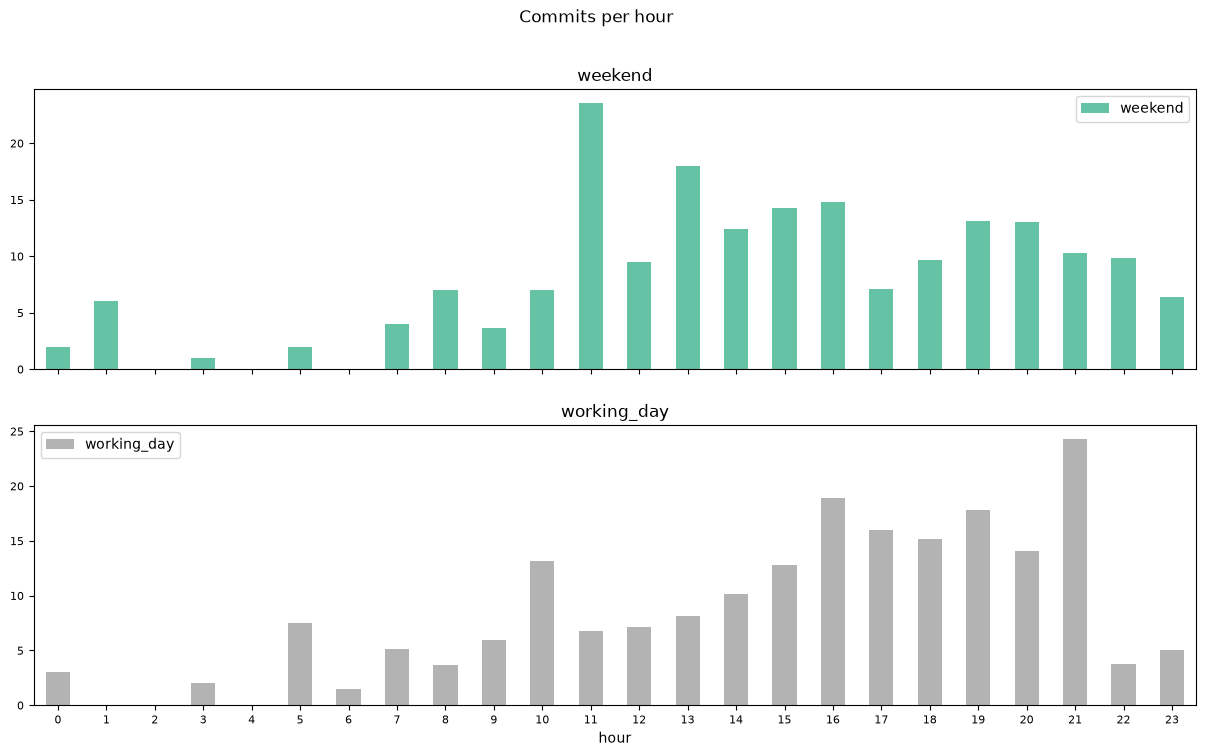

In [9]:
pivot.T.plot(
    kind='bar',
    subplots=True,
    title='Commits per hour',
    fontsize=8,
    figsize=(15, 8),
    rot=0,
    colormap='Set2'
)

Различается ли динамика в рабочие дни и в выходные?

In [10]:
top_working = pivot.loc['working_day'].idxmax()
top_weekend = pivot.loc['weekend'].idxmax()

print(f'Топ-час в рабочие дни: {top_working}, среднее количество коммитов: {pivot.loc['working_day', top_working]}')
print(f'Топ-час в выходные: {top_weekend}, среднее количество коммитов: {pivot.loc['weekend', top_weekend]}')

Топ-час в рабочие дни: 21, среднее количество коммитов: 24.333333333333332
Топ-час в выходные: 11, среднее количество коммитов: 23.6


In [11]:
conn.close()